# 1.Package Import

In [ ]:
from bmovie_code import gen_table1_subj_info
from pynwb import NWBHDF5IO
from pathlib import Path
import numpy as np
import pandas as pd

from new_code import data_summary, load_data_into_pds, load_data_into_dict, slicer, label, feature, utils

import pickle

In [2]:
%load_ext autoreload
%autoreload 2

# 2. Global file location (need to specify your own path)

In [3]:
NWB_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files"
BIDS_DIR="/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/bids_files"

In [4]:
gen_table1_subj_info.main(
    nwb_input_dir=NWB_DIR,
    bids_datadir=BIDS_DIR
)

In [5]:
# nwb_df, bids_df = data_summary.run_summary(NWB_DIR, BIDS_DIR, max_nwb_files=3, max_bids_files_each=5)

# nwb_df.head(), bids_df.head()

# 3. Load labels and data

In [5]:
# labels
with open("../assets/annotations/short_faceannots.pkl", "rb") as f:
    face_annots = pickle.load(f)

type(face_annots)
# print(list(face_annots.items())[:10])

path = "../assets/annotations/scenecut_info.csv"
scenecut_info = pd.read_csv(path)

print(scenecut_info.head())

   scene_id  shot_start_fr  shot_start_t  shot_dur_t  location cut_type  \
0       1.0            1.0          0.00        4.72  backyard      cut   
1       1.0          119.0          4.72       10.28  backyard      cut   
2       1.0          376.0         15.00        1.72  backyard      cut   
3       1.0          419.0         16.72        2.36  backyard      cut   
4       1.0          478.0         19.08        2.64  backyard      cut   

   cut_dur_t  cut_dur_fr  
0        0.0           0  
1        0.0           0  
2        0.0           0  
3        0.0           0  
4        0.0           0  


In [6]:
df_face_note = label.build_face_feature_df(face_annots, target_id="Jacky")
print(df_face_note.tail())

        frame_key  frame_idx  movie_time  n_faces  total_face_area  \
9373  frame_11898      11898      475.92        2      35470.00073   
9374  frame_11899      11899      475.96        2      35470.00073   
9375  frame_11900      11900      476.00        2      35470.00073   
9376  frame_11901      11901      476.04        2      35470.00073   
9377  frame_11902      11902      476.08        2      35470.00073   

      max_face_area  Jacky_present  any_front_face dominant_emotion  \
9373   24058.686485              0               1        surprised   
9374   24058.686485              0               1        surprised   
9375   24058.686485              0               1        surprised   
9376   24058.686485              0               1        surprised   
9377   24058.686485              0               1        surprised   

      emo_afraid  emo_angry  emo_happy  emo_neutral  emo_surprised  
9373       False      False      False        False           True  
9374       Fal

In [9]:
nwb_path = load_data_into_pds.find_nwb_file_for_subject(NWB_DIR, "CS41")
print("Using:", nwb_path)

io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
nwb = io.read()

print("\n=== acquisition keys ===")
print(list(nwb.acquisition.keys()))

print("\n=== processing modules ===")
print(list(nwb.processing.keys()))

for mod_name, mod in nwb.processing.items():
    print(f"\n--- processing[{mod_name}] keys ---")
    try:
        print(list(mod.data_interfaces.keys()))
    except Exception as e:
        print("cannot list data_interfaces:", e)

print("\n=== stimulus keys ===")
print(list(getattr(nwb, "stimulus", {}).keys()))

print("\n=== intervals ===")
print(list(getattr(nwb, "intervals", {}).keys()))

io.close()

Using: /Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb

=== acquisition keys ===
['events_ttl', 'experiment_ids']

=== processing modules ===
['behavior', 'ecephys']

--- processing[behavior] keys ---
['Blink', 'EyeTracking', 'Fixation', 'PupilTracking', 'Saccade']

--- processing[ecephys] keys ---
['LFP_macro', 'LFP_micro']

=== stimulus keys ===
['movieframe_time']

=== intervals ===
['trials']


In [10]:
from pynwb import NWBHDF5IO
io = NWBHDF5IO("/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb", "r", load_namespaces=True)
nwb = io.read()

ece = nwb.processing["ecephys"]
print("LFP_macro electrical_series keys:", list(ece["LFP_macro"].electrical_series.keys()))
print("LFP_micro electrical_series keys:", list(ece["LFP_micro"].electrical_series.keys()))

beh = nwb.processing["behavior"]
print("EyeTracking spatial_series keys:", list(beh["EyeTracking"].spatial_series.keys()))
print("PupilTracking time_series keys:", list(beh["PupilTracking"].time_series.keys()))

io.close()

LFP_macro electrical_series keys: ['ElectricalSeries']
LFP_micro electrical_series keys: ['ElectricalSeries']
EyeTracking spatial_series keys: ['SpatialSeries']
PupilTracking time_series keys: ['TimeSeries']


In [11]:
sub_nums = [41]

data = load_data_into_dict.load_multimodal_subjects_movie_aligned(
    sub_nums=[41],
    nwb_root=NWB_DIR,
    bids_root=BIDS_DIR,
    max_nwb_samples=2000000,
    grid_source= "lfp_raw",   # {"movie_frame_time", "uniform", "lfp_raw"}
    grid_dt = None,         # used when grid_source == "uniform"
    uniform_grid_include_baseline = True,

    compute_firing_rate= True,
    firing_rate_bin_width= None,  # if None, infer from t_grid
    compute_lfp_bandpower= True,
    lfp_bandpower_on_raw= True,       # recommended
    bands= None,

    # optional fmri
    load_fmri= False,
    fmri_max_runs= None,
)

print(data[41].keys())
print(data[41]['meta'])
print(data[41]["lfp_macro"].shape, data[41]["eye_gaze"].shape)
# print("n_units:", data[41]["meta"]["n_units"], "firing_rate:", data[41]["firing_rate"].shape)
print("band keys:", list(data[41]["lfp_bandpower"].keys()))
# data[41]["lfp_macro"][:, :5]
x = data[41]["lfp_macro"]
t = data[41]["time_grid"]
print(x.shape, len(t))

[sub 41] nwb_path=/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb
[sub 41] fs_macro=1000.0, fs_micro=1000.0, fs_eye=499.9999999976126
[sub 41] t_macro_movie range=(-10.000, 753.963)
[sub 41] movieframe_time(frame) range=(0.000, 11970.000)
[sub 41] movieframe_time_sec range=(0.000, 478.800)
[sub 41] t_grid len=763964 source=lfp_raw
dict_keys(['spikes', 'firing_rate', 'lfp_macro', 'lfp_micro', 'lfp_bandpower', 'eye_gaze', 'pupil', 'time_grid', 'movieframe_time', 'movieframe_time_sec', 'time_raw', 'bold', 'meta'])
{'sub': 41, 'bids_sub': 'p41cs', 'nwb_sub': 'CS41', 'nwb_path': '/Volumes/Extreme SSD/GT/PSYC8803/data/bmovie/nwb_files/000623/sub-CS41/sub-CS41_ses-P41CSR1_behavior+ecephys.nwb', 'fs_macro_raw': np.float64(1000.0), 'fs_micro_raw': np.float64(1000.0), 'fs_eye_raw': np.float64(499.9999999976126), 'movie_fps_nominal': 25.0, 'grid_source': 'lfp_raw', 'grid_dt': 0.000999999999990564, 'time_reference': 'movie_start_is_z

In [12]:
eye_data = data[41]["eye_gaze"]
print("movie_time shape:", data[41]["movieframe_time"].shape)
print("eye_gaze shape:", eye_data.shape)
print(eye_data[:5])

movie_time shape: (11971,)
eye_gaze shape: (763964, 2)
[[630. 548.]
 [630. 548.]
 [630. 548.]
 [630. 548.]
 [630. 548.]]


Text(0.5, 1.0, 'PCA Explained Variance')

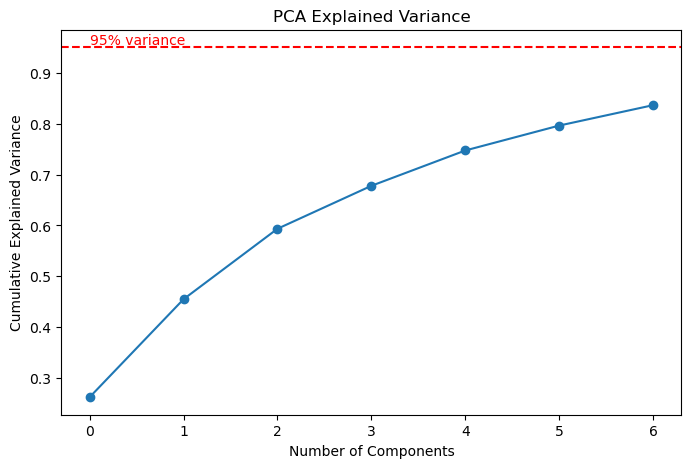

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

seg = slicer.slice_modalities_by_movie_time_sec(data[41], 0.0, 10.0)

X = seg["lfp_micro"]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% variance'
)

plt.text(
    x=0,
    y=0.95,
    s="95% variance",
    color='r',
    ha='left',
    va='bottom'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

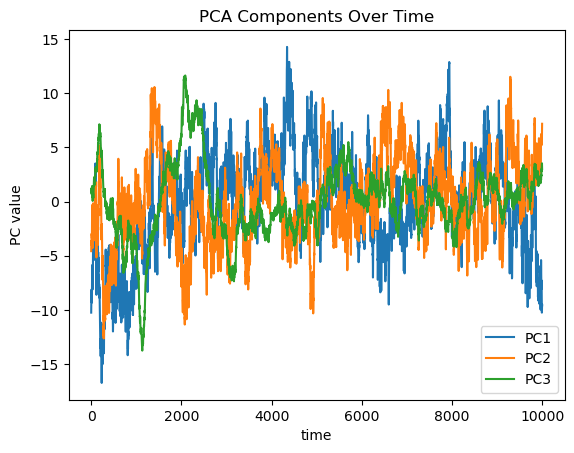

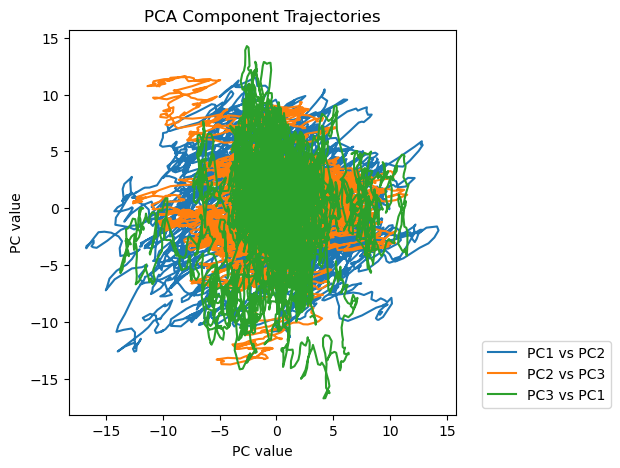

In [14]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.plot(X_pca[:, i], label=f'PC{i+1}')

plt.legend()
plt.xlabel("time")
plt.ylabel("PC value")
plt.title("PCA Components Over Time")
plt.show()

plt.figure(figsize=(5, 5))
for i in range(3):
    j = (i + 1) % 3
    plt.plot(X_pca[:, i], X_pca[:, j],label=f'PC{i+1} vs PC{j+1}')
    

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.xlabel("PC value")
plt.ylabel("PC value")
plt.title("PCA Component Trajectories")
plt.axis('equal')
plt.show()

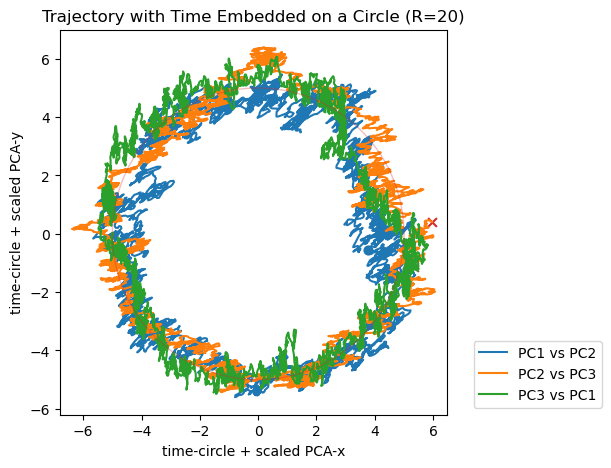

In [15]:
import numpy as np
import matplotlib.pyplot as plt

R = 5
T = X_pca.shape[0]
theta = np.linspace(0, 2*np.pi, T, endpoint=True)

plt.figure(figsize=(5, 5))

for i in range(3):
    j = (i + 1) % 3

    x = X_pca[:, i]
    y = X_pca[:, j]

    p95 = np.percentile(np.sqrt(x**2 + y**2), 95)
    s = (0.25 * R) / (p95 + 1e-9)

    cx = R * np.cos(theta)
    cy = R * np.sin(theta)

    X = cx + s * x
    Y = cy + s * y

    plt.plot(X, Y, label=f'PC{i+1} vs PC{j+1}')

    plt.scatter(X[0],  Y[0],  s=40, marker='o')
    plt.scatter(X[-1], Y[-1], s=40, marker='x')

tt = np.linspace(0, 2*np.pi, 400)
plt.plot(R*np.cos(tt), R*np.sin(tt), linewidth=1, alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 0), loc='lower left')
plt.axis('equal')
plt.xlabel("time-circle + scaled PCA-x")
plt.ylabel("time-circle + scaled PCA-y")
plt.title("Trajectory with Time Embedded on a Circle (R=20)")
plt.show()

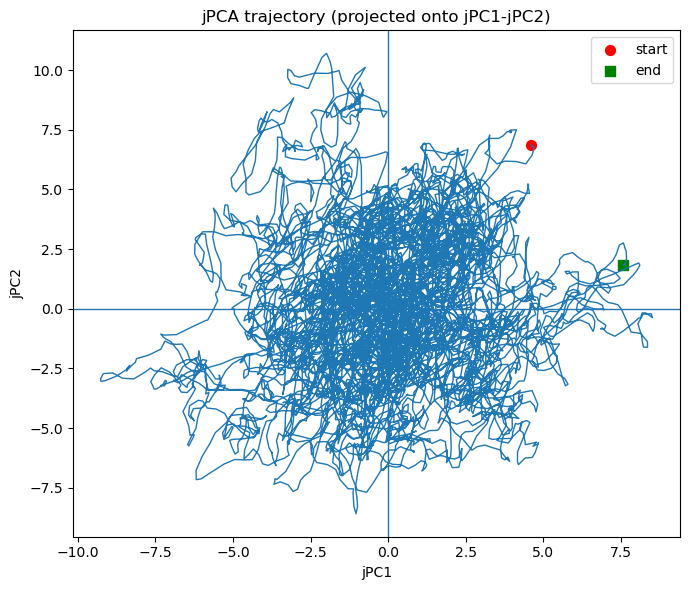

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def finite_diff(X, dt=1.0):
    """Centered finite difference for dX/dt (same length as X)."""
    dX = np.zeros_like(X)
    dX[1:-1] = (X[2:] - X[:-2]) / (2 * dt)
    dX[0]    = (X[1] - X[0]) / dt
    dX[-1]   = (X[-1] - X[-2]) / dt
    return dX

def fit_skew_M(X, dX):
    """
    Fit skew-symmetric M to minimize ||dX - X M^T||_F
    with constraint M^T = -M.
    """
    T, D = X.shape
    assert dX.shape == X.shape

    # Build linear system A m = b for upper-triangular free params of M
    # Parameterize M by entries m_ij for i<j, with:
    # M[i,j]=m_ij, M[j,i]=-m_ij, diag=0.
    pairs = [(i, j) for i in range(D) for j in range(i+1, D)]
    P = len(pairs)

    A = np.zeros((T * D, P), dtype=float)
    b = dX.reshape(-1)

    # For each time t and row k:
    # (X M^T)[t,k] = sum_l X[t,l] * M[k,l]
    # and M[k,l] expressed via m_ij.
    row = 0
    for t in range(T):
        x = X[t]
        for k in range(D):
            for p_idx, (i, j) in enumerate(pairs):
                val = 0.0
                # contribution from M[k,i] and M[k,j] if they exist
                # M[k,l] is:
                #  - if k==i and l==j: +m_ij
                #  - if k==j and l==i: -m_ij
                #  - if k==j and l==i handled similarly, etc.
                if k == i:
                    # term X[t, j] * M[i, j] = X_j * (+m_ij)
                    val += x[j]
                elif k == j:
                    # term X[t, i] * M[j, i] = X_i * (-m_ij)
                    val -= x[i]
                # also need terms where l==k and k==i/j? already covered above (since M[k,l])
                A[row, p_idx] = val
            row += 1

    # Solve least squares
    m_hat, *_ = np.linalg.lstsq(A, b, rcond=None)

    # Reconstruct M
    D = X.shape[1]
    M = np.zeros((D, D), dtype=float)
    for p_idx, (i, j) in enumerate(pairs):
        M[i, j] = m_hat[p_idx]
        M[j, i] = -m_hat[p_idx]
    return M

def jpca(X, dt=1.0, center=True):
    """
    X: (T, D) single trajectory (time-ordered).
    Returns:
      Xc: centered X used for fit
      M: skew-symmetric fitted dynamics
      W: (D,2) jPC plane basis
      Z: (T,2) projected trajectory in jPC plane
    """
    X_use = X.copy()
    if center:
        X_use = X_use - X_use.mean(axis=0, keepdims=True)

    dX = finite_diff(X_use, dt=dt)
    M = fit_skew_M(X_use, dX)

    # For skew-symmetric M, eigenvalues are ± iω. Take the pair with largest |ω|.
    evals, evecs = np.linalg.eig(M)
    omegas = np.abs(np.imag(evals))
    idx = np.argsort(omegas)[::-1]

    # pick the first eigenvector; its conjugate spans the same 2D plane
    v = evecs[:, idx[0]]
    W = np.column_stack([np.real(v), np.imag(v)])  # (D,2)

    # Orthonormalize W
    W, _ = np.linalg.qr(W)

    Z = X_use @ W
    return X_use, M, W, Z

# ====== X_pca jPCA ======
X = X_pca[:, :6]
dt = 1/30

Xc, M, W, Z = jpca(X, dt=dt, center=True)

# ====== jPC1 vs jPC2 ======
plt.figure(figsize=(7, 6))
plt.plot(Z[:, 0], Z[:, 1], lw=1)
plt.scatter(Z[0, 0], Z[0, 1], s=50, color='red', marker='o', label='start')
plt.scatter(Z[-1, 0], Z[-1, 1], s=50, color='green', marker='s', label='end')
plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xlabel("jPC1")
plt.ylabel("jPC2")
plt.title("jPCA trajectory (projected onto jPC1-jPC2)")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Face Encoding Model

In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def ridge_encoding_cv_single_output(X, y, alpha=10.0, n_splits=5):
    """
    contiguous block CV
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
    X = X[valid]
    y = y[valid]

    T = len(y)
    if T < n_splits:
        return {"corr": np.nan, "r2": np.nan, "pred": np.full(T, np.nan)}

    fold_edges = np.linspace(0, T, n_splits + 1).astype(int)
    preds = np.full(T, np.nan, dtype=float)

    for i in range(n_splits):
        te0, te1 = fold_edges[i], fold_edges[i + 1]
        te_idx = np.arange(te0, te1)
        tr_idx = np.setdiff1d(np.arange(T), te_idx)

        xtr, xte = X[tr_idx], X[te_idx]
        ytr = y[tr_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        xtr = x_scaler.fit_transform(xtr)
        xte = x_scaler.transform(xte)
        ytr_z = y_scaler.fit_transform(ytr[:, None]).ravel()

        model = Ridge(alpha=alpha)
        model.fit(xtr, ytr_z)

        yhat_z = model.predict(xte)
        yhat = y_scaler.inverse_transform(yhat_z[:, None]).ravel()
        preds[te_idx] = yhat

    valid_pred = np.isfinite(preds)
    if valid_pred.sum() < 3:
        return {"corr": np.nan, "r2": np.nan, "pred": preds}

    yv = y[valid_pred]
    pv = preds[valid_pred]

    corr = np.corrcoef(yv, pv)[0, 1] if np.std(yv) > 0 and np.std(pv) > 0 else np.nan
    r2 = 1.0 - np.sum((yv - pv) ** 2) / np.sum((yv - np.mean(yv)) ** 2) if np.var(yv) > 0 else np.nan

    return {"corr": corr, "r2": r2, "pred": preds}

def flatten_targets(Y, target_prefix):
    """
    Input
    -----
    Y:
      [T]                  -> 1 target
      [T, C]               -> C targets
      [T, C, B]            -> C*B targets

    Returns
    -------
    Y2d: [T, N_targets]
    target_names: list[str]
    """
    Y = np.asarray(Y, dtype=float)

    if Y.ndim == 1:
        return Y[:, None], [f"{target_prefix}_0"]

    elif Y.ndim == 2:
        n = Y.shape[1]
        names = [f"{target_prefix}_{i}" for i in range(n)]
        return Y, names

    elif Y.ndim == 3:
        T, A, B = Y.shape
        Y2d = Y.reshape(T, A * B)
        names = [f"{target_prefix}_{a}_{b}" for a in range(A) for b in range(B)]
        return Y2d, names

    else:
        raise ValueError(f"Unsupported Y.ndim={Y.ndim}")
    
def run_encoding_for_modality(
    X,
    Y,
    modality_name,
    alpha=10.0,
    n_splits=5,
    max_targets=None,
):
    """
    X: [T, D]
    Y: [T], [T, C], or [T, C, B]
    """
    Y2d, target_names = flatten_targets(Y, modality_name)

    if max_targets is not None:
        Y2d = Y2d[:, :max_targets]
        target_names = target_names[:max_targets]

    rows = []
    for j, target_name in enumerate(target_names):
        y = Y2d[:, j]
        res = ridge_encoding_cv_single_output(X, y, alpha=alpha, n_splits=n_splits)

        rows.append({
            "modality": modality_name,
            "target": target_name,
            "corr": res["corr"],
            "r2": res["r2"],
        })

    return pd.DataFrame(rows)

def run_face_encoding_all_modalities(
    df_face_note,
    sub_dict,
    face_feature_sets,
    method_map=None,
    lags_sec=(-0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5),
    alpha=10.0,
    n_splits=5,
    max_targets_per_modality=None,
):
    t_grid = np.asarray(sub_dict["time_grid"], dtype=float)
    dt = float(np.median(np.diff(t_grid)))
    lags = np.round(np.asarray(lags_sec) / dt).astype(int)

    all_face_cols = sorted(set(sum(face_feature_sets.values(), [])))

    df_face_grid = slicer.resample_face_df_to_timegrid(
        df_face_note,
        t_grid,
        all_face_cols,
        method_map=method_map,
    )

    results = []

    for model_name, cols in face_feature_sets.items():
        X = df_face_grid[cols].astype(float).to_numpy()
        X_lag = feature.make_lagged_matrix(X, lags)

        modality_specs = {
            "firing_rate": sub_dict.get("firing_rate", None),
            "lfp_macro": sub_dict.get("lfp_macro", None),
            "lfp_micro": sub_dict.get("lfp_micro", None),
            "lfp_bandpower": sub_dict.get("lfp_bandpower", None),
            "pupil": sub_dict.get("pupil", None),
            "eye_gaze": sub_dict.get("eye_gaze", None),
        }

        for modality_name, Y in modality_specs.items():
            if Y is None:
                continue

            try:
                df_res = run_encoding_for_modality(
                    X=X_lag,
                    Y=Y,
                    modality_name=modality_name,
                    alpha=alpha,
                    n_splits=n_splits,
                    max_targets=max_targets_per_modality,
                )
                df_res["model_name"] = model_name
                results.append(df_res)
            except Exception as e:
                results.append(pd.DataFrame([{
                    "modality": modality_name,
                    "target": None,
                    "corr": np.nan,
                    "r2": np.nan,
                    "model_name": model_name,
                    "error": repr(e),
                }]))

    if len(results) == 0:
        return pd.DataFrame()

    return pd.concat(results, axis=0, ignore_index=True)

In [19]:
face_feature_sets = {
    "quantity": ["n_faces", "total_face_area", "max_face_area"],
    "identity": ["Jacky_present"],
    "pose_emotion": [
        "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ],
    "all_face": [
        "n_faces", "total_face_area", "max_face_area",
        "Jacky_present", "any_front_face",
        "emo_afraid", "emo_angry", "emo_happy",
        "emo_neutral", "emo_surprised"
    ]
}

method_map = {
    "n_faces": "nearest",
    "total_face_area": "linear",
    "max_face_area": "linear",
    "Jacky_present": "nearest",
    "any_front_face": "nearest",
    "emo_afraid": "nearest",
    "emo_angry": "nearest",
    "emo_happy": "nearest",
    "emo_neutral": "nearest",
    "emo_surprised": "nearest",
}

sub = list(data.keys())[0]

df_result = run_face_encoding_all_modalities(
    df_face_note=df_face_note,
    sub_dict=data[sub],
    face_feature_sets=face_feature_sets,
    method_map=method_map,
    lags_sec=(-0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.5),
    alpha=10.0,
    n_splits=5,
    max_targets_per_modality=20,
)

print(df_result)

          modality         target      corr        r2 model_name  \
0      firing_rate  firing_rate_0 -0.001604 -0.000094   quantity   
1      firing_rate  firing_rate_1  0.000022 -0.000036   quantity   
2      firing_rate  firing_rate_2 -0.000203 -0.000063   quantity   
3      firing_rate  firing_rate_3  0.001573 -0.000032   quantity   
4      firing_rate  firing_rate_4  0.002523 -0.000035   quantity   
..             ...            ...       ...       ...        ...   
199      lfp_micro   lfp_micro_19  0.034573 -0.052330   all_face   
200  lfp_bandpower           None       NaN       NaN   all_face   
201          pupil        pupil_0  0.148087 -0.014405   all_face   
202       eye_gaze     eye_gaze_0 -0.063445 -0.095297   all_face   
203       eye_gaze     eye_gaze_1 -0.106102 -0.146655   all_face   

                                                 error  
0                                                  NaN  
1                                                  NaN  
2           

In [20]:
df_result.groupby(["modality", "model_name"])[["corr", "r2"]].mean()

corr        r2
modality      model_name                      
eye_gaze      all_face     -0.084774 -0.120976
              identity     -0.117075 -0.038549
              pose_emotion -0.099240 -0.100063
              quantity     -0.056059 -0.029604
firing_rate   all_face      0.000251 -0.000532
              identity     -0.000398 -0.000037
              pose_emotion  0.000279 -0.000428
              quantity     -0.000483 -0.000067
lfp_bandpower all_face           NaN       NaN
              identity           NaN       NaN
              pose_emotion       NaN       NaN
              quantity           NaN       NaN
lfp_macro     all_face      0.001814 -0.101092
              identity      0.003659 -0.000846
              pose_emotion -0.001217 -0.096995
              quantity     -0.001450 -0.002747
lfp_micro     all_face      0.030872 -0.075891
              identity     -0.014368 -0.001532
              pose_emotion  0.011048 -0.063668
              quantity      0.057969 -0.000214
pupil         all_face      0.148087 -0.014405
              identity      0.107573  0.003979
              pose_emotion  0.129494 -0.016544
              quantity      0.164033  0.021730


===== firing_rate =====


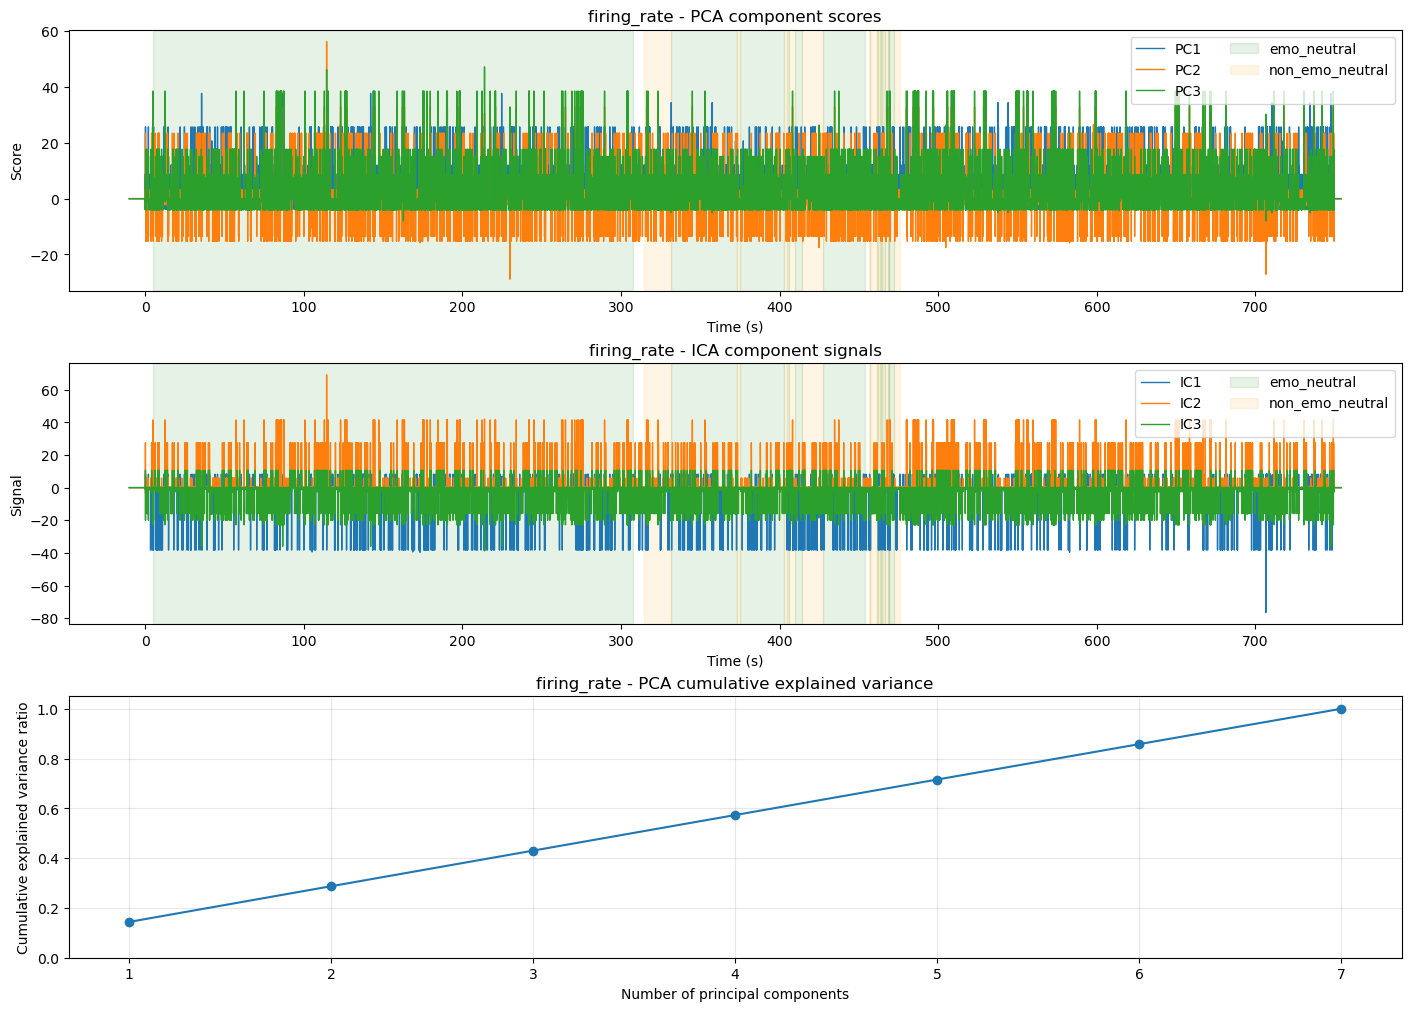


===== lfp_macro =====


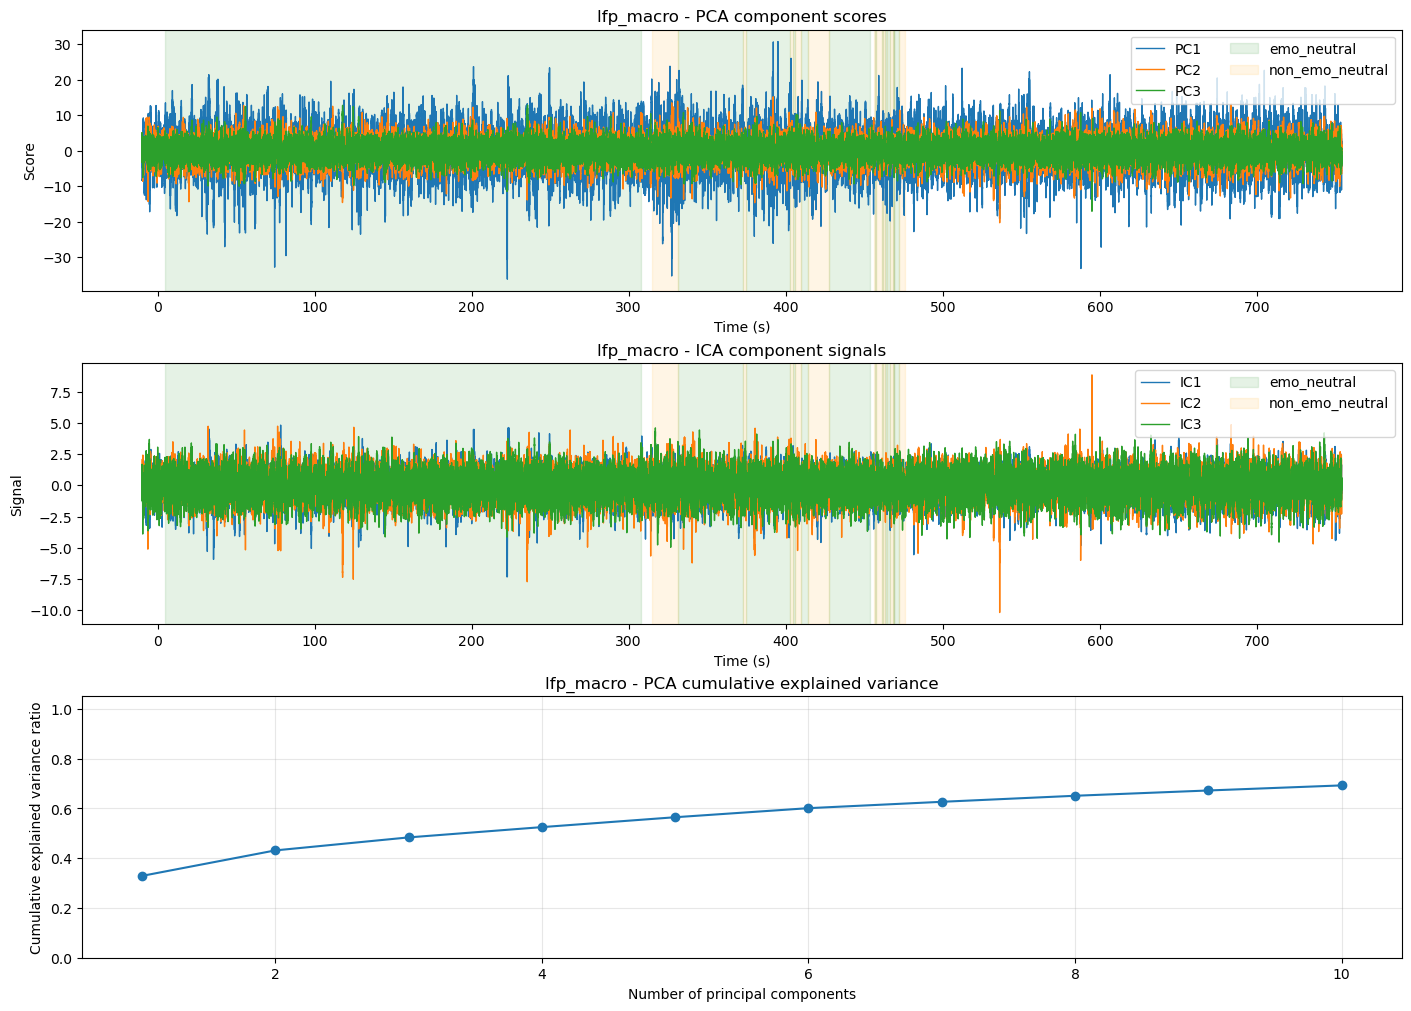


===== lfp_micro =====


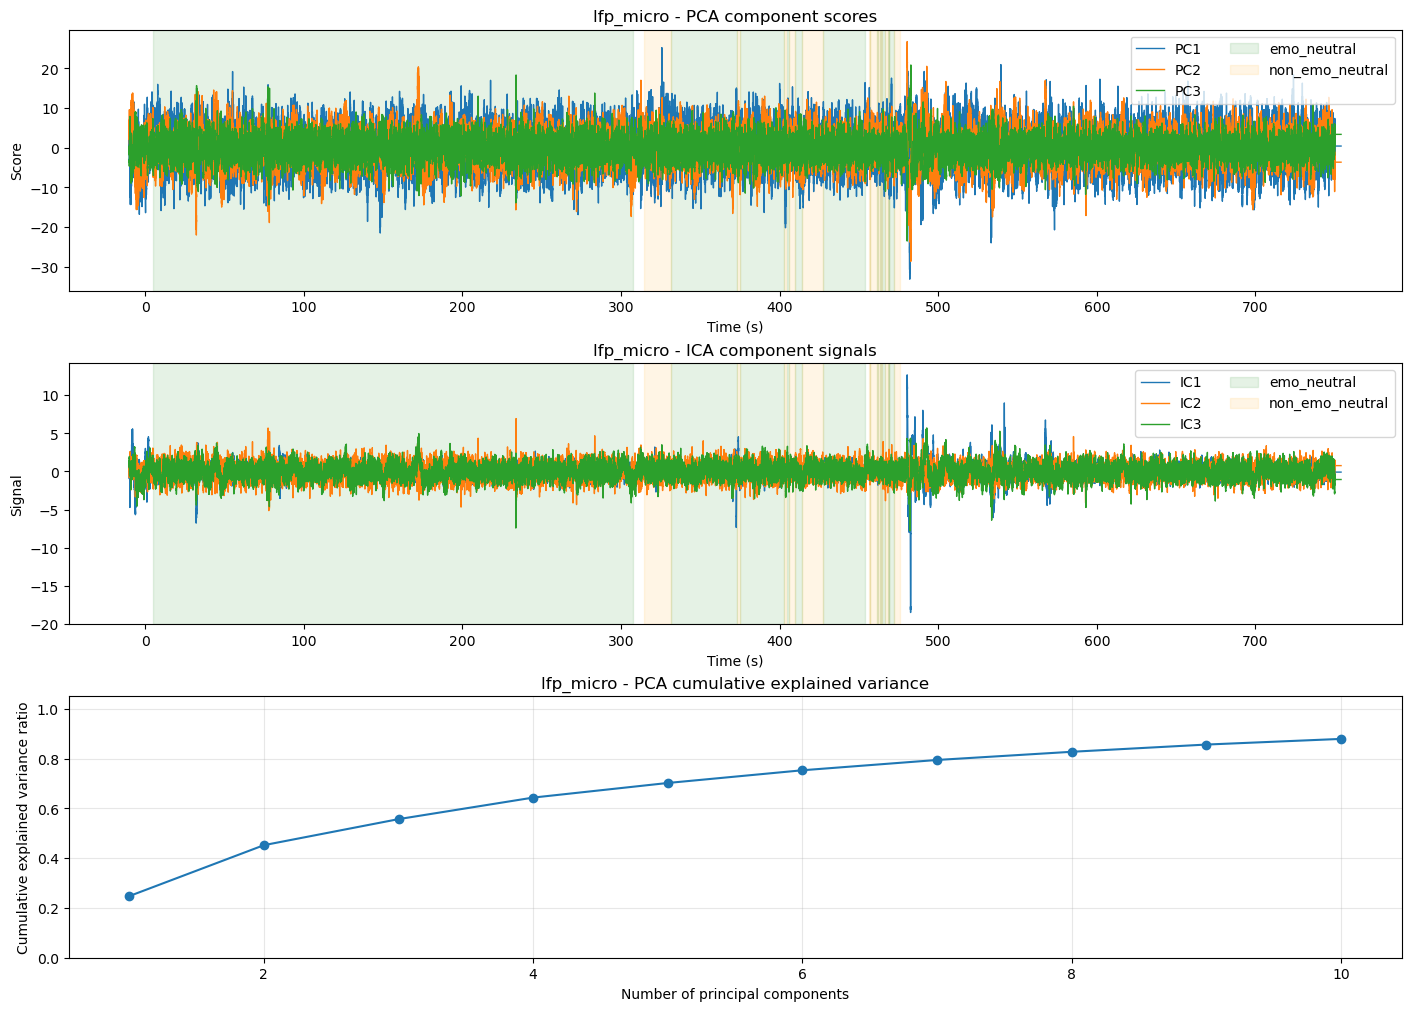


===== eye_gaze =====


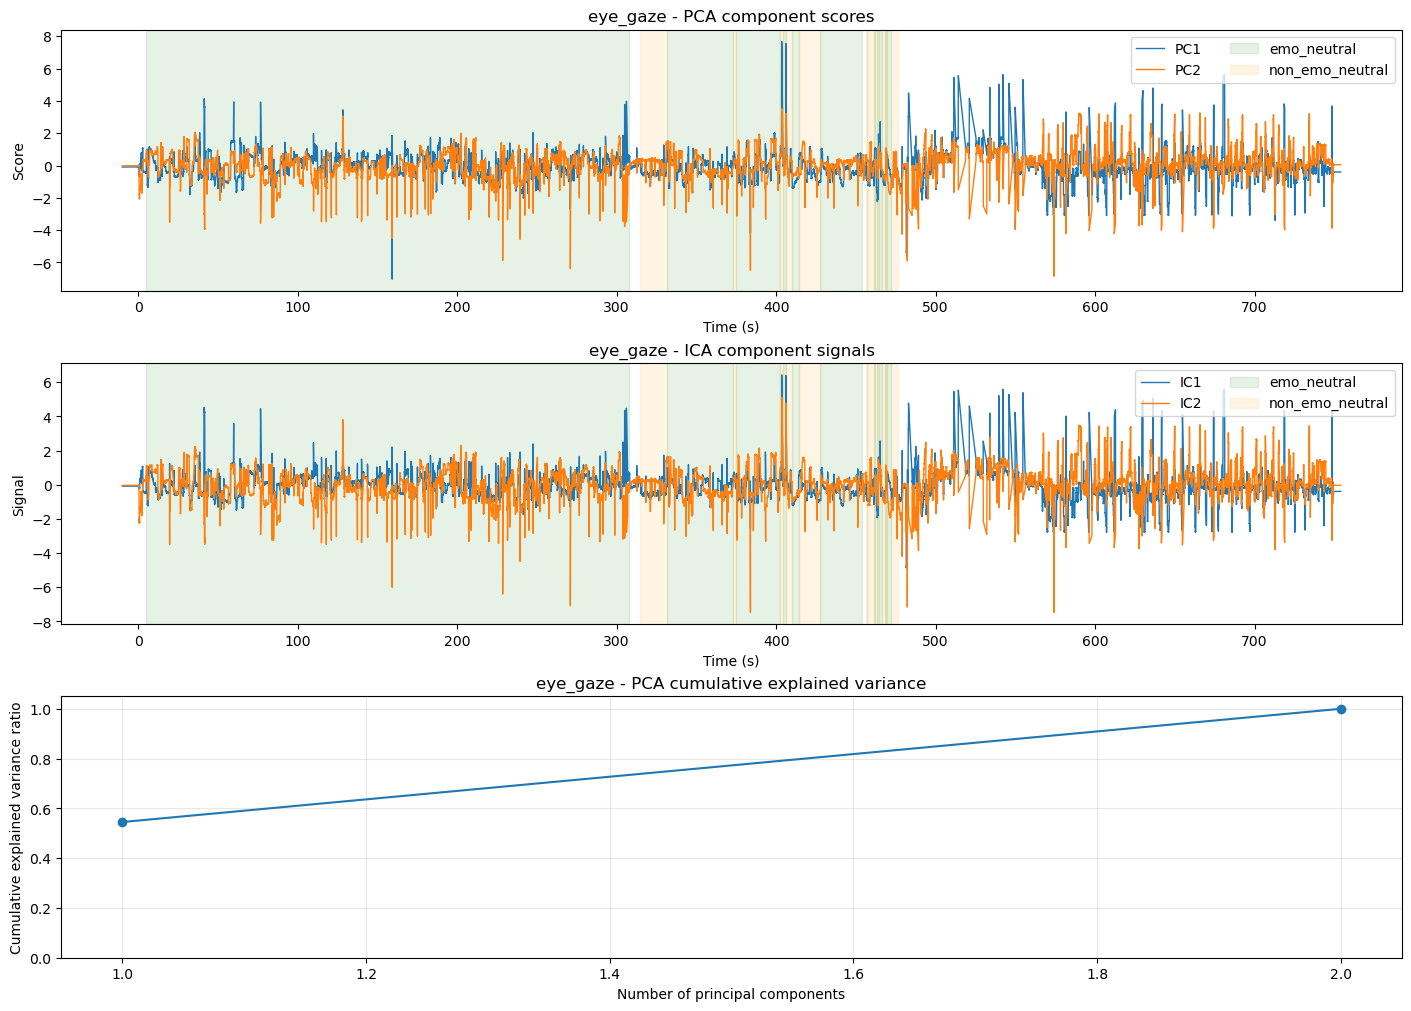


===== pupil =====
[skip] pupil: effective feature dim < 2 after cleaning


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler


# =========================
# 1. 基础工具
# =========================
def _ensure_2d_time_by_feature(x, target_len=None, name="modality"):
    """
    尽量把输入整理成 [T, D] 形式。
    支持:
      - 1D: [T] -> [T, 1]
      - 2D: [T, D] or [D, T]
      - 3D+: 若某一维等于 target_len，则把那一维移到前面并 flatten 其余维
    """
    if x is None:
        return None

    x = np.asarray(x, dtype=np.float64)

    if x.ndim == 1:
        return x[:, None]

    if x.ndim == 2:
        # 如果给了 target_len，就优先让第一维=T
        if target_len is not None:
            if x.shape[0] == target_len:
                return x
            elif x.shape[1] == target_len:
                return x.T
        # 否则默认第一维是时间
        return x

    # ndim >= 3
    if target_len is not None:
        axes = list(range(x.ndim))
        time_axis = None
        for ax, s in enumerate(x.shape):
            if s == target_len:
                time_axis = ax
                break
        if time_axis is not None:
            x = np.moveaxis(x, time_axis, 0)   # [T, ...]
            T = x.shape[0]
            return x.reshape(T, -1)

    # fallback: 默认第一维是时间
    T = x.shape[0]
    return x.reshape(T, -1)


def _fill_nan_2d(X):
    """
    对 [T, D] 矩阵按列填 NaN:
    - 先用列均值填
    - 若整列全 NaN，则填 0
    """
    X = np.asarray(X, dtype=np.float64).copy()
    col_mean = np.nanmean(X, axis=0)

    # 整列全nan -> nanmean会是nan，这里置0
    col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)

    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_mean, inds[1])
    return X


def get_time_axis_for_modality(sub_data, modality):
    """
    给每个模态找一个时间轴（秒）。
    优先：
      1) resampled continuous modality -> time_grid
      2) 若长度和 movieframe_time_sec 一致 -> movieframe_time_sec
      3) 若存在 raw time -> time_raw[...]
    """
    arr = sub_data.get(modality, None)
    if arr is None:
        return None

    time_grid = np.asarray(sub_data.get("time_grid", []), dtype=np.float64)
    movie_t = np.asarray(sub_data.get("movieframe_time_sec", []), dtype=np.float64)

    # raw time
    time_raw_dict = sub_data.get("time_raw", {})
    raw_key_map = {
        "lfp_macro": "lfp_macro",
        "lfp_micro": "lfp_micro",
        "eye_gaze": "eye",
        "pupil": "eye",
    }
    raw_t = None
    if modality in raw_key_map and raw_key_map[modality] in time_raw_dict:
        raw_t = time_raw_dict[raw_key_map[modality]]
        if raw_t is not None:
            raw_t = np.asarray(raw_t, dtype=np.float64)

    # 先猜长度
    candidate = _ensure_2d_time_by_feature(arr, target_len=len(time_grid), name=modality)
    if candidate is not None and len(time_grid) > 0 and candidate.shape[0] == len(time_grid):
        return time_grid

    if len(movie_t) > 0:
        candidate = _ensure_2d_time_by_feature(arr, target_len=len(movie_t), name=modality)
        if candidate is not None and candidate.shape[0] == len(movie_t):
            return movie_t

    if raw_t is not None:
        candidate = _ensure_2d_time_by_feature(arr, target_len=len(raw_t), name=modality)
        if candidate is not None and candidate.shape[0] == len(raw_t):
            return raw_t

    # fallback
    X = _ensure_2d_time_by_feature(arr, target_len=None, name=modality)
    if X is None:
        return None
    return np.arange(X.shape[0], dtype=np.float64)


# =========================
# 2. annotation 区间提取
# =========================
def extract_boolean_spans(time_arr, flag_arr):
    """
    根据 time_arr 和布尔 flag_arr 提取连续区间 [(start, end), ...]
    """
    time_arr = np.asarray(time_arr, dtype=np.float64)
    flag_arr = np.asarray(flag_arr).astype(bool)

    assert len(time_arr) == len(flag_arr)

    spans = []
    if len(time_arr) == 0:
        return spans

    in_span = False
    start_t = None

    for i in range(len(flag_arr)):
        if flag_arr[i] and not in_span:
            in_span = True
            start_t = time_arr[i]
        elif (not flag_arr[i]) and in_span:
            end_t = time_arr[i - 1]
            spans.append((start_t, end_t))
            in_span = False
            start_t = None

    if in_span:
        spans.append((start_t, time_arr[-1]))

    return spans


def get_emotion_spans(df_face):
    """
    从 face annotation dataframe 中提取
      - neutral spans
      - non-neutral spans
    需要列:
      - movie_time
      - emo_neutral
    """
    df = df_face.copy().sort_values("movie_time").reset_index(drop=True)

    if "emo_neutral" not in df.columns:
        raise ValueError("df_face 里没有 'emo_neutral' 列")
    if "movie_time" not in df.columns:
        raise ValueError("df_face 里没有 'movie_time' 列")

    movie_time = df["movie_time"].to_numpy(dtype=np.float64)
    neutral_flag = df["emo_neutral"].astype(bool).to_numpy()
    nonneutral_flag = ~neutral_flag

    neutral_spans = extract_boolean_spans(movie_time, neutral_flag)
    nonneutral_spans = extract_boolean_spans(movie_time, nonneutral_flag)

    return neutral_spans, nonneutral_spans


def add_emotion_spans(ax, neutral_spans, nonneutral_spans,
                      neutral_alpha=0.10, nonneutral_alpha=0.10):
    """
    在时间图上标注 neutral / non-neutral 区间
    """
    # neutral: 浅绿色
    for i, (s, e) in enumerate(neutral_spans):
        ax.axvspan(
            s, e,
            alpha=neutral_alpha,
            color="green",
            label="emo_neutral" if i == 0 else None
        )

    # non-neutral: 浅橙色
    for i, (s, e) in enumerate(nonneutral_spans):
        ax.axvspan(
            s, e,
            alpha=nonneutral_alpha,
            color="orange",
            label="non_emo_neutral" if i == 0 else None
        )


# =========================
# 3. 单模态 PCA/ICA + 作图
# =========================
def analyze_one_modality(
    sub_data,
    modality,
    df_face,
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
    figsize=(14, 10)
):
    """
    对一个模态:
      - 整理成 [T, D]
      - PCA
      - ICA
      - 画:
          1) PCA前几个score的时间图
          2) ICA前几个source的时间图
          3) PCA累计解释方差图
    """
    arr = sub_data.get(modality, None)
    if arr is None:
        print(f"[skip] {modality}: not found in sub_data")
        return None

    t = get_time_axis_for_modality(sub_data, modality)
    if t is None:
        print(f"[skip] {modality}: no valid time axis")
        return None

    X = _ensure_2d_time_by_feature(arr, target_len=len(t), name=modality)
    if X is None:
        print(f"[skip] {modality}: cannot convert to 2D")
        return None

    # 再检查一下长度是否匹配
    if X.shape[0] != len(t):
        print(f"[skip] {modality}: time length mismatch, X={X.shape}, len(t)={len(t)}")
        return None

    # 去掉全常数列/全nan列前先填nan
    X = _fill_nan_2d(X)

    # 去掉方差为0的列
    col_std = np.std(X, axis=0)
    keep = col_std > 1e-12
    X = X[:, keep]

    if X.shape[1] < 2:
        print(f"[skip] {modality}: effective feature dim < 2 after cleaning")
        return None

    # 标准化
    if standardize:
        scaler = StandardScaler()
        Xz = scaler.fit_transform(X)
    else:
        Xz = X.copy()

    # PCA
    pca_k = min(n_pca, Xz.shape[0], Xz.shape[1])
    pca = PCA(n_components=pca_k, random_state=0)
    X_pca = pca.fit_transform(Xz)
    cumvar = np.cumsum(pca.explained_variance_ratio_)

    # ICA
    ica_k = min(n_ica, Xz.shape[0], Xz.shape[1])
    ica = FastICA(n_components=ica_k, random_state=0, max_iter=2000, tol=1e-4)
    try:
        X_ica = ica.fit_transform(Xz)
        ica_ok = True
    except Exception as e:
        print(f"[warn] {modality}: ICA failed -> {e}")
        X_ica = None
        ica_ok = False

    # emotion spans
    neutral_spans, nonneutral_spans = get_emotion_spans(df_face)

    # ========== Plot ==========
    fig, axes = plt.subplots(3, 1, figsize=figsize, constrained_layout=True)

    # 1) PCA score time series
    ax = axes[0]
    n_show_pca = min(plot_n_comp, X_pca.shape[1])
    for i in range(n_show_pca):
        ax.plot(t, X_pca[:, i], label=f"PC{i+1}", linewidth=1.0)
    add_emotion_spans(ax, neutral_spans, nonneutral_spans)
    ax.set_title(f"{modality} - PCA component scores")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Score")
    ax.legend(loc="upper right", ncol=2)

    # 2) ICA source time series
    ax = axes[1]
    if ica_ok and X_ica is not None:
        n_show_ica = min(plot_n_comp, X_ica.shape[1])
        for i in range(n_show_ica):
            ax.plot(t, X_ica[:, i], label=f"IC{i+1}", linewidth=1.0)
        add_emotion_spans(ax, neutral_spans, nonneutral_spans)
        ax.set_title(f"{modality} - ICA component signals")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Signal")
        ax.legend(loc="upper right", ncol=2)
    else:
        ax.text(0.5, 0.5, f"ICA failed for {modality}", ha="center", va="center", fontsize=12)
        ax.set_title(f"{modality} - ICA component signals")
        ax.set_axis_off()

    # 3) Cumulative explained variance
    ax = axes[2]
    ax.plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o")
    ax.set_title(f"{modality} - PCA cumulative explained variance")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative explained variance ratio")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

    plt.show()

    return {
        "modality": modality,
        "time": t,
        "X": X,
        "pca_model": pca,
        "pca_scores": X_pca,
        "cum_explained_variance": cumvar,
        "ica_model": ica if ica_ok else None,
        "ica_sources": X_ica,
        "neutral_spans": neutral_spans,
        "nonneutral_spans": nonneutral_spans,
    }


# =========================
# 4. 批量分析多个模态
# =========================
def analyze_modalities(
    sub_data,
    df_face,
    modalities=None,
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
):
    if modalities is None:
        modalities = [
            "firing_rate",
            "lfp_macro",
            "lfp_micro",
            "lfp_bandpower",
            "eye_gaze",
            "pupil",
        ]

    results = {}
    for modality in modalities:
        print(f"\n===== {modality} =====")
        res = analyze_one_modality(
            sub_data=sub_data,
            modality=modality,
            df_face=df_face,
            n_pca=n_pca,
            n_ica=n_ica,
            standardize=standardize,
            plot_n_comp=plot_n_comp,
        )
        results[modality] = res

    return results
results = analyze_modalities(
    sub_data=data[sub],
    df_face=df_face_note,
    modalities=[
        "firing_rate",
        "lfp_macro",
        "lfp_micro",
        "eye_gaze",
        "pupil",
    ],
    n_pca=10,
    n_ica=5,
    standardize=True,
    plot_n_comp=3,
)

In [22]:
from numpy.linalg import lstsq, eig
from scipy.signal import detrend

def compute_jpca(X, dt):
    """
    X: [T, D]
    dt: scalar
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"X must be 2D, got shape={X.shape}")
    if X.shape[0] < 3:
        raise ValueError(f"Need at least 3 time points, got shape={X.shape}")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError(f"dt must be positive finite, got dt={dt}")

    # 对齐成:
    # X_prev[t] 对应 dX[t] = (X[t+1]-X[t]) / dt
    X_prev = X[:-1]                    # [T-1, D]
    dX = np.diff(X, axis=0) / dt       # [T-1, D]

    # fit: dX = X_prev @ M
    M, _, _, _ = lstsq(X_prev, dX, rcond=None)   # M shape [D, D]

    # 旋转部分
    M_skew = 0.5 * (M - M.T)

    eigvals, eigvecs = eig(M_skew)
    return M, M_skew, eigvals, eigvecs

def project_to_jpca_plane(X, eigvecs, eigvals):
    """
    取虚部最大的那一对特征向量，构造2D jPCA plane
    """
    imag_strength = np.abs(np.imag(eigvals))
    idx = np.argsort(imag_strength)[-2:]

    W = np.real(eigvecs[:, idx])   # [D, 2]
    X_jpca = X @ W                 # [T, 2]
    return X_jpca, W, idx


def plot_jpca_trajectory(X_jpca, modality):
    plt.figure(figsize=(5, 5))
    plt.plot(X_jpca[:, 0], X_jpca[:, 1], linewidth=1)
    plt.scatter(X_jpca[0, 0], X_jpca[0, 1], label="start")
    plt.scatter(X_jpca[-1, 0], X_jpca[-1, 1], label="end")
    plt.xlabel("jPC1")
    plt.ylabel("jPC2")
    plt.title(f"{modality} jPCA plane")
    plt.legend()
    plt.axis("equal")
    plt.show()


def run_jpca_on_result(res, n_input_pc=6):
    X = np.asarray(res["pca_scores"], dtype=np.float64)
    X = detrend(X, axis=0)
    t = np.asarray(res["time"], dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(f"pca_scores must be 2D, got {X.shape}")
    if len(t) != X.shape[0]:
        raise ValueError(f"time length {len(t)} != X rows {X.shape[0]}")
    if len(t) < 3:
        raise ValueError(f"Need at least 3 time points, got {len(t)}")

    # 去掉非有限时间差
    dt_all = np.diff(t)
    dt_all = dt_all[np.isfinite(dt_all) & (dt_all > 0)]
    if len(dt_all) == 0:
        raise ValueError("No valid positive dt found in time axis")
    dt = np.median(dt_all)

    # 限制输入维数
    k = min(n_input_pc, X.shape[1])
    X = X[:, :k]

    # 去掉含nan的行
    good = np.isfinite(X).all(axis=1) & np.isfinite(t)
    X = X[good]
    t = t[good]

    if X.shape[0] < 3:
        raise ValueError(f"Not enough valid rows after cleaning: {X.shape}")

    M, M_skew, eigvals, eigvecs = compute_jpca(X, dt)
    X_jpca, W, idx = project_to_jpca_plane(X, eigvecs, eigvals)

    plot_jpca_trajectory(X_jpca, res["modality"])

    print(f"{res['modality']} | input_dim={k}, T={X.shape[0]}, dt={dt:.6f}")
    print("eigenvalues:", eigvals)
    print("imag parts:", np.imag(eigvals))

    return {
        "X_jpca": X_jpca,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "W": W,
        "idx": idx,
        "M": M,
        "M_skew": M_skew,
        "dt": dt,
    }


==== firing_rate ====


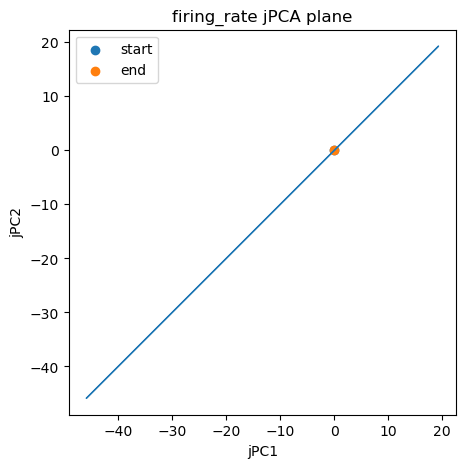

firing_rate | input_dim=6, T=763964, dt=0.001000
eigenvalues: [ 4.40086804e-17+2.83914177j  4.40086804e-17-2.83914177j
 -9.62957421e-17+0.51151306j -9.62957421e-17-0.51151306j
  2.04237390e-17+1.31989734j  2.04237390e-17-1.31989734j]
imag parts: [ 2.83914177 -2.83914177  0.51151306 -0.51151306  1.31989734 -1.31989734]

==== lfp_macro ====


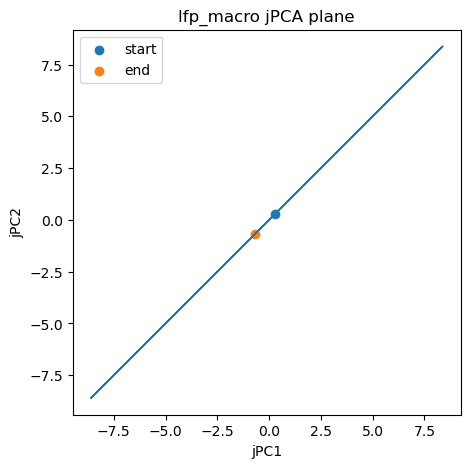

lfp_macro | input_dim=6, T=763964, dt=0.001000
eigenvalues: [-2.11696297e-16+8.08011304j -2.11696297e-16-8.08011304j
 -8.88178420e-16+5.30883137j -8.88178420e-16-5.30883137j
  1.96201344e-16+0.67839599j  1.96201344e-16-0.67839599j]
imag parts: [ 8.08011304 -8.08011304  5.30883137 -5.30883137  0.67839599 -0.67839599]

==== lfp_micro ====


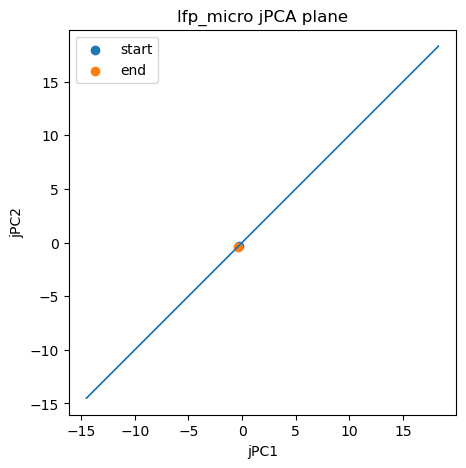

lfp_micro | input_dim=6, T=763964, dt=0.001000
eigenvalues: [ 1.79040669e-16+4.85629942j  1.79040669e-16-4.85629942j
 -7.54271327e-17+1.51554634j -7.54271327e-17-1.51554634j
  6.60840152e-20+0.24945952j  6.60840152e-20-0.24945952j]
imag parts: [ 4.85629942 -4.85629942  1.51554634 -1.51554634  0.24945952 -0.24945952]

==== eye_gaze ====


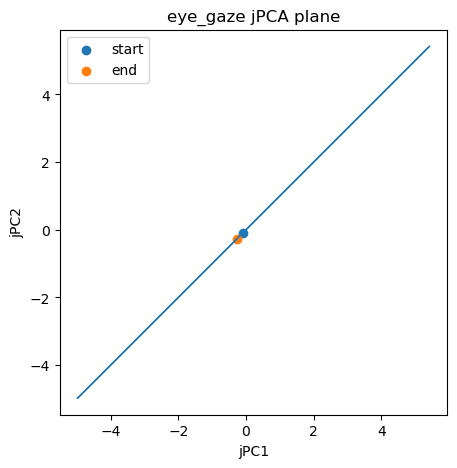

eye_gaze | input_dim=2, T=763964, dt=0.001000
eigenvalues: [0.+0.0241269j 0.-0.0241269j]
imag parts: [ 0.0241269 -0.0241269]


In [23]:
jpca_results = {}

for modality, res in results.items():
    if res is None:
        continue

    print("\n====", modality, "====")
    try:
        jpca_results[modality] = run_jpca_on_result(res, n_input_pc=6)
    except Exception as e:
        print(f"[skip] {modality}: {e}")